In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [ ]:
# Shape -> (Row, Col)
df.shape

(891, 12)

In [ ]:
# Info -> Non-null + Data Count + Data Type Variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Missing Value Percentage
df.isnull().sum()/df.shape[0]*100

# Hasil Analisis:
# Age -> 19.87%
# Cabin -> 77.10%
# Embarked -> 0.22%

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [ ]:
# finding duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
for i in df.select_dtypes(include="object").columns:
	print(df[i].value_counts())
	print("***"*10)

Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64
******************************
Sex
male      577
female    314
Name: count, dtype: int64
******************************
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
3734

In [ ]:
df.describe().T

# Count, Unique, Top, Frequency dari Data Object
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


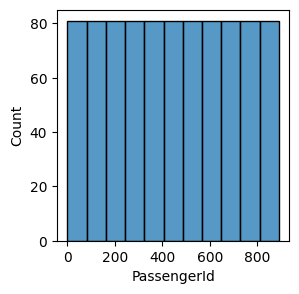

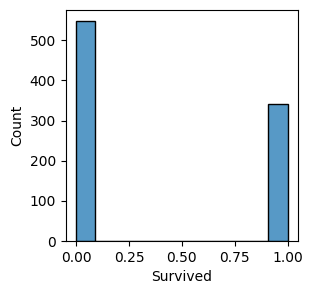

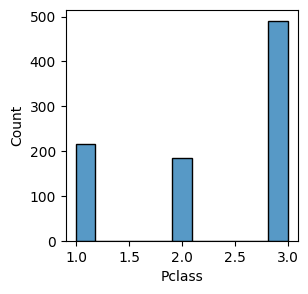

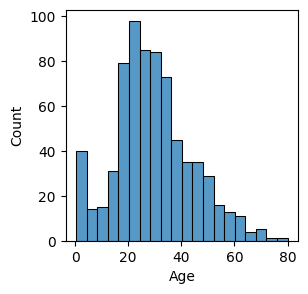

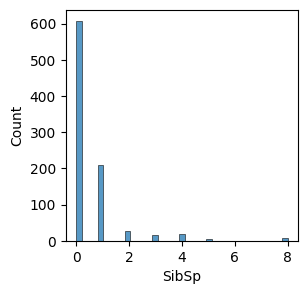

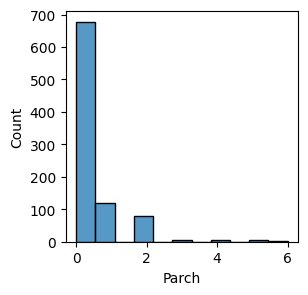

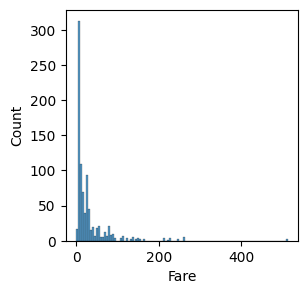

In [ ]:
for i in df.select_dtypes(include="number").columns:
	plt.figure(figsize=(3,3))
	sns.histplot(data=df, x=i)
	plt.show()

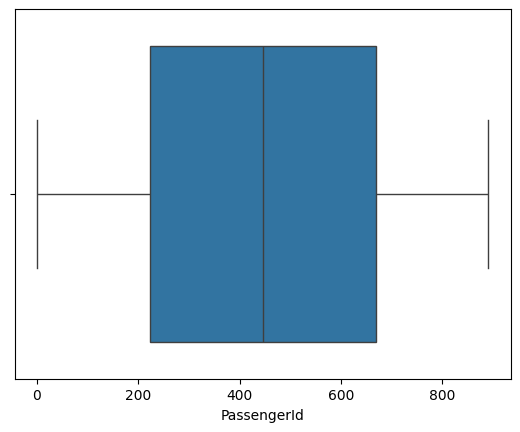

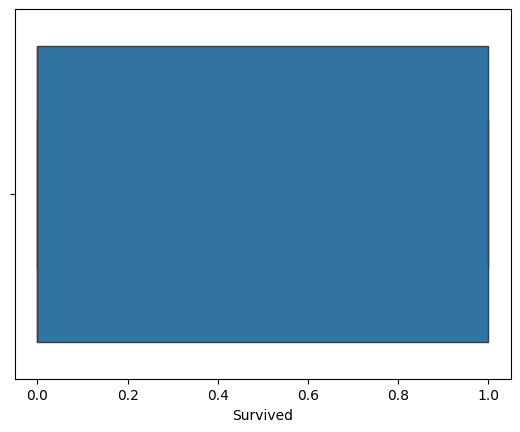

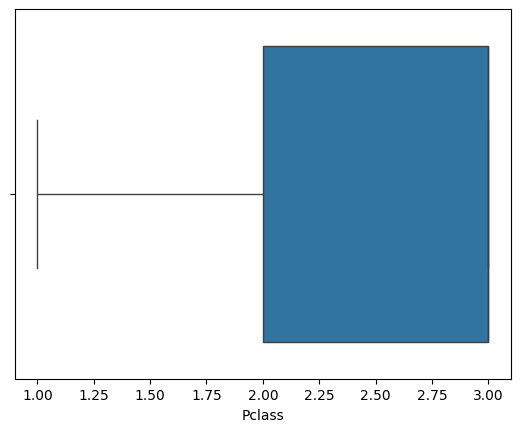

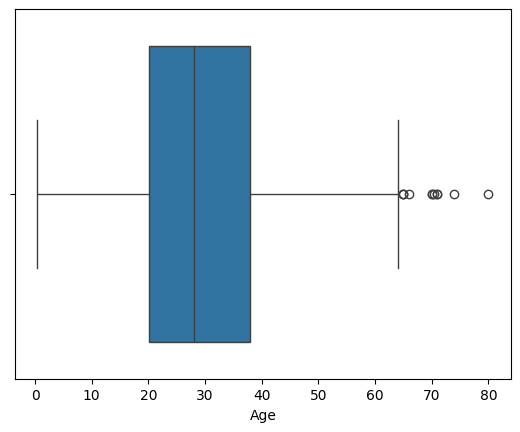

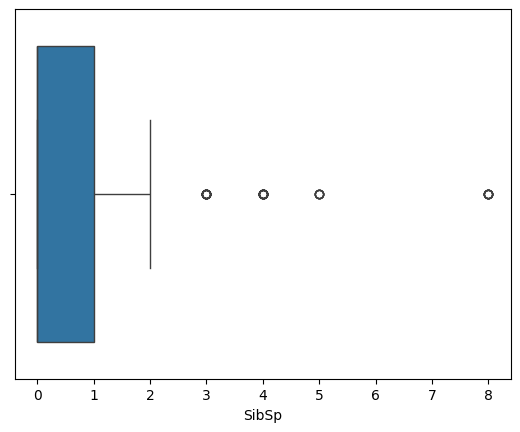

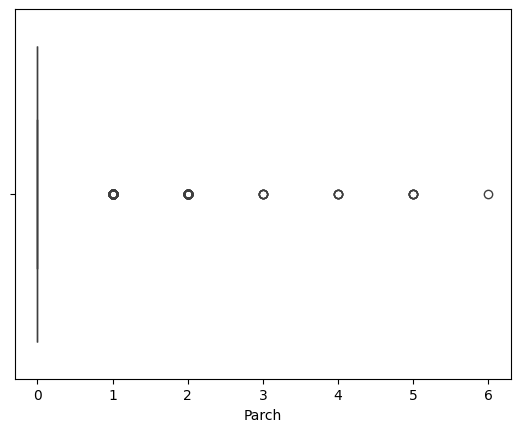

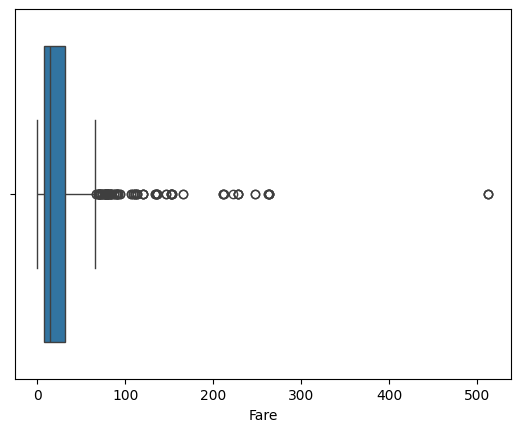

In [ ]:
for i in df.select_dtypes(include="number").columns:
	sns.boxplot(data=df, x=i)
	plt.show()

	# Age (Umur): Distribusinya cukup normal
	# Fare (Tarif): Masalah: Sangat skewed (miring) ke kanan
	# SibSp & Parch (Keluarga):Mayoritas nilainya adalah 0 (Ga ada yang aneh)
	# PassengerId: Ga ada yang aneh karena naiknya terus

<Axes: >

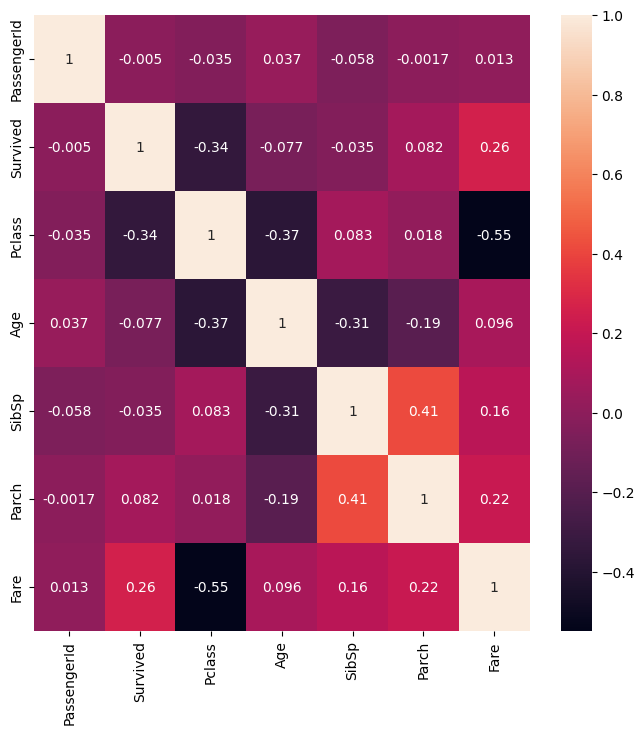

In [ ]:
s = df.select_dtypes(include="number").corr()

# Heatmap
plt.figure(figsize=(8,8))
sns.heatmap(s, annot=True)

# Hasil Analisi:
# Strongest Correlation (Survived):
# 1. Pclass (-0.34): Korelasi Negatif Terkuat
# 2. Fare (+0.26): Korelasi Positif Terkuat
# 3. Age (-0.077): Korelasi Lemah.
# Multicollinearity:
# SibSp vs Parch (+0.41) -> Moderate Correlation
# PassengerId (~0.00): Ga ada korelasi dengan yang lain


In [ ]:
# Missing Value Handling
for i in ["Age", "Fare"]:
    if i in df.columns:
        df[i].fillna(df[i].median(), inplace=True)

for i in ["Embarked"]:
    if i in df.columns:
        df[i].fillna(df[i].mode()[0], inplace=True)

df.drop(columns=['Cabin'], inplace=True) # Karena lebih dari 50% missing value dan ga terlalu kepakai

/tmp/ipython-input-3605007353.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(), inplace=True)
/tmp/ipython-input-3605007353.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

In [ ]:
# Outliers Handling Fare
# Selain fare outliersnya masuk akal
# Fare outliersnya dihandle pake log transformation biar ga terlalu ekstrim dan bikin skewd jadi distribusi normal

df['Fare'] = df['Fare'].map(lambda x: np.log1p(x))

In [ ]:
# Encoding Categorical Variable

df.info()

# One Hot Encoding
df = pd.get_dummies(data = df, columns = ["Sex", "Embarked"], drop_first=True)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,2.110213,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,4.280593,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,2.188856,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,3.990834,False,False,True
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,2.202765,True,False,True


Confusion Matrix:
 [[136  21]
 [ 30  81]]
True Negative  : 136
False Positive : 21
False Negative : 30
True Positive  : 81
Performance Metrics
Accuracy Score : 0.8097
Precision Score: 0.7941
Recall Score   : 0.7297
ROC-AUC Score  : 0.8856
f1 Score      : 0.7606
Roc Curve Plotting


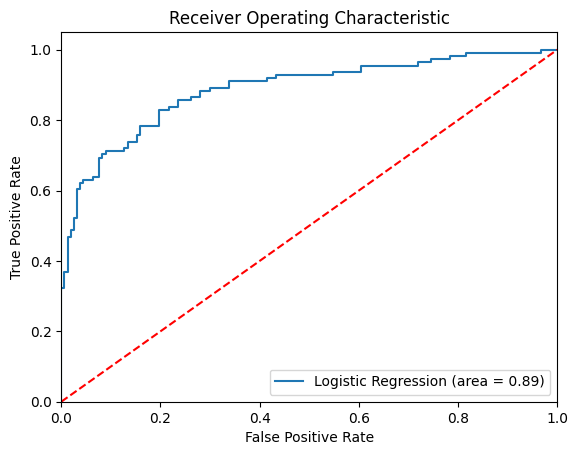

In [ ]:
# Logistic Regression
X = df.drop(['Name', 'Ticket', 'PassengerId', 'Survived'], axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

from sklearn.metrics import confusion_matrix, roc_auc_score
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]

TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()
# Ada cara lain make cm = confusion_matrix(y_test, y_pred) terus cm[0,0] as TN, cm[0,1] as FP, cm[1,0] as FN, cm[1,1] as TP

print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print(f"True Negative  : {TN}")
print(f"False Positive : {FP}")
print(f"False Negative : {FN}")
print(f"True Positive  : {TP}")
print("==="*10)

print("Performance Metrics")
print(f"Accuracy Score : {(TN + TP) / (TN + FP + FN + TP):.4f}")
print(f"Precision Score: {TP / (TP + FP):.4f}")
print(f"Recall Score   : {TP / (TP + FN):.4f}")
print(f"ROC-AUC Score  : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"f1 Score      : {2 * ( (TP / (TP + FP)) * (TP / (TP + FN)) ) / ( (TP / (TP + FP)) + (TP / (TP + FN)) ) :.4f}")
print("==="*10)
print("Roc Curve Plotting")
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % roc_auc_score(y_test, y_pred_proba))
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()